## Import necessary libs

In [2]:
!pip install pydantic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 53.3 MB/s eta 0:00:00


In [75]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [76]:
import os
import sys
import shutil
import matplotlib.pyplot as plt

sys.path.append('..')
from libs.datasets import UnlearnDatasetCifar, UnlearnDatasetSplitMode, UnlearnDatasetSplit

from PIL import Image
import matplotlib.pyplot as plt
import random
import torch
import numpy as np
from functools import partial
from typing import Literal, List, Dict, Tuple, Optional, Callable, Union

import os
import sys
import shutil

# import necessary libs
import torch.optim
import torch.utils.data
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data.sampler import SubsetRandomSampler

## Install necessary libs

In [12]:
!pip install --upgrade Pillow
!pip install torchmetrics
!pip install image_similarity_measures
!pip install lpips
!pip install pyfftw
!pip install torch_fidelity

In [13]:
sys.path.append('Unlearn-Saliency')
sys.path.append('Unlearn-Saliency/metrics/')
sys.path.append('Unlearn-Saliency/utils/')

from libs.metrics import ClassificationAccuracy

## Download, split and save dataset

In [14]:
main_folder = os.getcwd()
print(main_folder)

/media/DiscoLocal/IPCV/Carolina/Unlearn-Saliency/tests


In [15]:
# dowload and split dataset
root_dataset = main_folder + '/Datasets'
os.makedirs(root_dataset, exist_ok=True)

dataset = UnlearnDatasetCifar(
    download_path = root_dataset,
    split_mode = UnlearnDatasetSplitMode.Class,
    split_kwargs = {
        'forget': ['cat','frog']
    },
)

print('loaded dataset...')

loader = dataset.get_loader(UnlearnDatasetSplit.Train_forget, 256)
print(len(loader))

100%|██████████| 170498071/170498071 [00:06<00:00, 25868258.64it/s]


Extracting /media/DiscoLocal/IPCV/Carolina/Unlearn-Saliency/tests/Datasets/cifar-10-python.tar.gz to /media/DiscoLocal/IPCV/Carolina/Unlearn-Saliency/tests/Datasets
Files already downloaded and verified
loaded dataset...
36


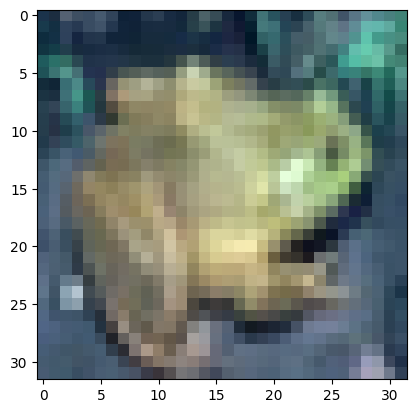

In [20]:
tensor = next(iter(loader))[0][0]
image = (tensor - tensor.min()) / (tensor.max() - tensor.min())
image = image.permute(1, 2, 0).numpy()
plt.imshow(image)

In [21]:
print(len(dataset._dataset_splits[UnlearnDatasetSplit.Test_forget]))

2000


## Train base model

In [22]:
# configure cuda
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU is available")
else:
    device = torch.device("cpu")
    print("GPU is not available, using CPU")

GPU is available


In [23]:
import random
# configure seeds for reproducibility
def setup_seed(seed):
    print("setup random seed = {}".format(seed))
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

In [24]:
class NormalizeByChannelMeanStd(torch.nn.Module):
    def __init__(self, mean, std):
        super(NormalizeByChannelMeanStd, self).__init__()
        if not isinstance(mean, torch.Tensor):
            mean = torch.tensor(mean)
        if not isinstance(std, torch.Tensor):
            std = torch.tensor(std)
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, tensor):
        return self.normalize_fn(tensor, self.mean, self.std)

    '''def extra_repr(self):
        return "mean={}, std={}".format(self.mean, self.std)'''

    def normalize_fn(self, tensor, mean, std):
        """Differentiable version of torchvision.functional.normalize"""
        # here we assume the color channel is in at dim=1
        mean = mean[None, :, None, None]
        std = std[None, :, None, None]
        return tensor.sub(mean).div(std)

# configure ResNet module to the available classes
class ResNet(torch.nn.Module):
    def __init__(
        self,
        block,
        layers,
        num_classes=1000,
        zero_init_residual=False,
        groups=1,
        width_per_group=64,
        replace_stride_with_dilation=None,
        norm_layer=None,
        imagenet=False,
    ):
        super(ResNet, self).__init__()
        if norm_layer is None:
            norm_layer = torch.nn.BatchNorm2d
        self._norm_layer = norm_layer

        self.inplanes = 64
        self.dilation = 1
        if replace_stride_with_dilation is None:
            # each element in the tuple indicates if we should replace
            # the 2x2 stride with a dilated convolution instead
            replace_stride_with_dilation = [False, False, False]
        if len(replace_stride_with_dilation) != 3:
            raise ValueError(
                "replace_stride_with_dilation should be None "
                "or a 3-element tuple, got {}".format(replace_stride_with_dilation)
            )
        self.groups = groups
        self.base_width = width_per_group

        print("The normalize layer is contained in the network")
        self.normalize = NormalizeByChannelMeanStd(
            mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616]
        )

        if not imagenet:
            self.conv1 = torch.nn.Conv2d(
                3, self.inplanes, kernel_size=3, stride=1, padding=1, bias=False
            )
            self.bn1 = norm_layer(self.inplanes)
            self.relu = torch.nn.ReLU(inplace=True)
            self.maxpool = torch.nn.Identity()
        else:
            self.conv1 = torch.nn.Conv2d(
                3, self.inplanes, kernel_size=7, stride=2, padding=3, bias=False
            )
            self.bn1 = torch.nn.BatchNorm2d(self.inplanes)
            self.relu = torch.nn.ReLU(inplace=True)
            self.maxpool = torch.nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(
            block, 128, layers[1], stride=2, dilate=replace_stride_with_dilation[0]
        )
        self.layer3 = self._make_layer(
            block, 256, layers[2], stride=2, dilate=replace_stride_with_dilation[1]
        )
        self.layer4 = self._make_layer(
            block, 512, layers[3], stride=2, dilate=replace_stride_with_dilation[2]
        )
        self.avgpool = torch.nn.AdaptiveAvgPool2d((1, 1))
        self.fc = torch.nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, torch.nn.Conv2d):
                torch.nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, (torch.nn.BatchNorm2d, torch.nn.GroupNorm)):
                torch.nn.init.constant_(m.weight, 1)
                torch.nn.init.constant_(m.bias, 0)

        # Zero-initialize the last BN in each residual branch,
        # so that the residual branch starts with zeros, and each residual block behaves like an identity.
        # This improves the model by 0.2~0.3% according to https://arxiv.org/abs/1706.02677
        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    torch.nn.init.constant_(m.bn3.weight, 0)
                elif isinstance(m, BasicBlock):
                    torch.nn.init.constant_(m.bn2.weight, 0)

    def _make_layer(self, block, planes, blocks, stride=1, dilate=False):
        norm_layer = self._norm_layer
        downsample = None
        previous_dilation = self.dilation
        if dilate:
            self.dilation *= stride
            stride = 1
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = torch.nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                norm_layer(planes * block.expansion),
            )

        layers = []
        layers.append(
            block(
                self.inplanes,
                planes,
                stride,
                downsample,
                self.groups,
                self.base_width,
                previous_dilation,
                norm_layer,
            )
        )
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(
                block(
                    self.inplanes,
                    planes,
                    groups=self.groups,
                    base_width=self.base_width,
                    dilation=self.dilation,
                    norm_layer=norm_layer,
                )
            )

        return torch.nn.Sequential(*layers)

    def _forward_impl(self, x):
        # See note [TorchScript super()]
        x = self.normalize(x)

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x

    def forward(self, x):
        return self._forward_impl(x)

class BasicBlock(torch.nn.Module):
    expansion = 1
    __constants__ = ["downsample"]

    def __init__(
        self,
        inplanes,
        planes,
        stride=1,
        downsample=None,
        groups=1,
        base_width=64,
        dilation=1,
        norm_layer=None,
    ):
        super(BasicBlock, self).__init__()
        if norm_layer is None:
            norm_layer = torch.nn.BatchNorm2d
        if groups != 1 or base_width != 64:
            raise ValueError("BasicBlock only supports groups=1 and base_width=64")
        if dilation > 1:
            raise NotImplementedError("Dilation > 1 not supported in BasicBlock")
        # Both self.conv1 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = norm_layer(planes)
        self.relu = torch.nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = norm_layer(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

In [25]:
def conv3x3(in_planes, out_planes, stride=1, groups=1, dilation=1):
    """3x3 convolution with padding"""
    return torch.nn.Conv2d(
        in_planes,
        out_planes,
        kernel_size=3,
        stride=stride,
        padding=dilation,
        groups=groups,
        bias=False,
        dilation=dilation,
    )

def conv1x1(in_planes, out_planes, stride=1):
    """1x1 convolution"""
    return torch.nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)

# configure model used by SalUn testing
def _resnet(arch, block, layers, pretrained, progress, **kwargs):
    model = ResNet(block, layers, **kwargs)
    
    return model


def resnet18(pretrained=False, progress=True, **kwargs):
    r"""ResNet-18 model from
    `"Deep Residual Learning for Image Recognition" <https://arxiv.org/pdf/1512.03385.pdf>`_

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    return _resnet("resnet18", BasicBlock, [2, 2, 2, 2], pretrained, progress, **kwargs)

model = resnet18(num_classes=dataset._n_classes)
model.cuda()

The normalize layer is contained in the network


ResNet(
  (normalize): NormalizeByChannelMeanStd()
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(6

In [26]:
# train function

def warmup_lr(epoch, step, optimizer, one_epoch_step, warmup, lr_set):
    overall_steps = warmup * one_epoch_step
    current_steps = epoch * one_epoch_step + step

    lr = lr * current_steps / overall_steps
    lr = min(lr, lr_set)

    for p in optimizer.param_groups:
        p["lr"] = lr


def save_checkpoint(state, is_SA_best, save_path, pruning, filename="checkpoint.pth.tar"):
    filepath = os.path.join(save_path, str(pruning) + filename)
    torch.save(state, filepath)
    if is_SA_best:
        shutil.copyfile(
            filepath, os.path.join(save_path, str(pruning) + "model_SA_best.pth.tar")
        )

def accuracy(output, target, topk=(1,)):
    """Computes the precision@k for the specified values of k"""
    maxk = max(topk)
    batch_size = target.size(0)

    _, pred = output.topk(maxk, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))

    res = []
    for k in topk:
        correct_k = correct[:k].view(-1).float().sum(0)
        res.append(correct_k.mul_(100.0 / batch_size))
    return res

def validate(val_loader, model, criterion, print_freq):
    """
    Run evaluation
    """
    losses = []
    top1 = []

    # switch to evaluate mode
    model.eval()

    for i, (image, target) in enumerate(val_loader):
        image = image.cuda()
        target = target.cuda()

        # compute output
        with torch.no_grad():
            output = model(image)
            loss = criterion(output, target)

        output = output.float()
        loss = loss.float()

        # measure accuracy and record loss
        prec1 = accuracy(output.data, target)[0]
        losses.append(loss.item())
        top1.append(prec1.item())

        if i % print_freq == 0:
            print(f"Test: [{i}/{len(val_loader)}]\tLoss {losses[i]:.4f} ({np.mean(losses):.4f})\tAccuracy {top1[i]:.3f} ({np.mean(top1):.3f})")

    print(f"valid_accuracy {np.mean(top1):.3f}")

    return np.mean(top1)


def train(train_loader, model, criterion, optimizer, epoch, warmup, lr, alpha, print_freq, mask=None, l1=False):
    losses = []
    top1 = []

    # switch to train mode
    model.train()

    start = time.time()

    for i, (image, target) in enumerate(train_loader):
        if epoch < warmup:
            warmup_lr(epoch, i + 1, optimizer, len(train_loader), warmup, lr)

        image = image.cuda()
        target = target.cuda()

        # compute output
        output_clean = model(image)

        loss = criterion(output_clean, target)
        if l1:
            loss = loss + alpha * l1_regularization(model)
        optimizer.zero_grad()
        loss.backward()

        if mask:
            for name, param in model.named_parameters():
                if param.grad is not None:
                    param.grad *= mask[name]

        optimizer.step()

        output = output_clean.float()
        loss = loss.float()
        # measure accuracy and record loss
        prec1 = accuracy(output.data, target)[0]

        losses.append(loss.item())
        top1.append(prec1.item())

        if (i + 1) % print_freq == 0:
            end = time.time()
            print(f"Epoch: [{epoch}][{i}/{len(train_loader)}]\tLoss {losses[i]:.4f} ({np.mean(losses):.4f})\tAccuracy {top1[i]:.3f} ({np.mean(top1):.3f})\tTime {(end - start):.2f}")
            start = time.time()

    print(f"train_accuracy {np.mean(top1):.3f}")

    return np.mean(top1)

In [28]:
# define saving dir for model and checkpoints
save_dir = main_folder + '/Models'
os.makedirs(save_dir, exist_ok=True)

In [29]:
# define parameters
decreasing_lr = "91,136"
lr = 0.1
momentum = 0.9
batch_size = 256
weight_decay = 5e-4
epochs = 12
alpha = 0.2
warmup = 0
print_f = 50

In [30]:
import time

best_sa = 0
setup_seed(2)

train_loader = dataset.get_loader(UnlearnDatasetSplit.Train,
    batchsize=batch_size,
    num_workers=0,
    pin_memory=True,
    shuffle=True,
)
val_loader = dataset.get_loader(UnlearnDatasetSplit.Validation,
    batchsize=batch_size,
    num_workers=0,
    pin_memory=True,
    shuffle=True,
)

print('created loaders...')

print(f"number of train dataset {len(train_loader)}")
print(f"number of val dataset {len(val_loader)}")

criterion = torch.nn.CrossEntropyLoss()

decreasing_lr = list(map(int, [91, 136]))

optimizer = torch.optim.SGD(
    model.parameters(),
    lr,
    momentum=momentum,
    weight_decay=weight_decay,
)

scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, milestones=decreasing_lr, gamma=0.1
)  # 0.1 is fixed

all_result = {}
all_result["train_ta"] = []
all_result["test_ta"] = []
all_result["val_ta"] = []

start_epoch = 0
state = 0

for epoch in range(start_epoch, epochs):
    start_time = time.time()
    print(
        "Epoch #{}, Learning rate: {}".format(
            epoch, optimizer.state_dict()["param_groups"][0]["lr"]
        )
    )
    acc = train(train_loader, model, criterion, optimizer, epoch,  warmup, lr, alpha, print_f)

    # evaluate on validation set
    tacc = validate(val_loader, model, criterion, print_f)
    scheduler.step()

    all_result["train_ta"].append(acc)
    all_result["val_ta"].append(tacc)

    # remember best prec@1 and save checkpoint
    is_best_sa = tacc > best_sa
    best_sa = max(tacc, best_sa)

    save_checkpoint(
        {
            "result": all_result,
            "epoch": epoch + 1,
            "state_dict": model.state_dict(),
            "best_sa": best_sa,
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
        },
        is_SA_best=is_best_sa,
        pruning=state,
        save_path=save_dir,
    )
    print("one epoch duration:{}".format(time.time() - start_time))

# plot training curve
plt.plot(all_result["train_ta"], label="train_acc")
plt.plot(all_result["val_ta"], label="val_acc")
plt.legend()
plt.savefig(os.path.join(save_dir, str(state) + "net_train.png"))
plt.close()

print("Performance on the test data set")
test_tacc = validate(val_loader, model, criterion, print_f)
if len(all_result["val_ta"]) != 0:
    val_pick_best_epoch = np.argmax(np.array(all_result["val_ta"]))
    print(
        "* best SA = {}, Epoch = {}".format(
            all_result["val_ta"][val_pick_best_epoch], val_pick_best_epoch + 1
        )
    )

setup random seed = 2
created loaders...
number of train dataset 176
number of val dataset 20
Epoch #0, Learning rate: 0.1
Epoch: [0][49/176]	Loss 1.9670 (2.7924)	Accuracy 26.172 (17.695)	Time 7.31
Epoch: [0][99/176]	Loss 1.7495 (2.3375)	Accuracy 39.453 (22.945)	Time 6.73
Epoch: [0][149/176]	Loss 1.6752 (2.1261)	Accuracy 37.891 (27.294)	Time 6.77
train_accuracy 29.126
Test: [0/20]	Loss 1.6929 (1.6929)	Accuracy 41.016 (41.016)
valid_accuracy 36.803
one epoch duration:25.61350965499878
Epoch #1, Learning rate: 0.1
Epoch: [1][49/176]	Loss 1.5247 (1.5003)	Accuracy 44.922 (45.305)	Time 6.73
Epoch: [1][99/176]	Loss 1.2457 (1.4537)	Accuracy 53.125 (46.645)	Time 6.81
Epoch: [1][149/176]	Loss 1.3194 (1.4142)	Accuracy 53.516 (48.104)	Time 6.80
train_accuracy 48.938
Test: [0/20]	Loss 1.3224 (1.3224)	Accuracy 51.172 (51.172)
valid_accuracy 48.030
one epoch duration:25.96870493888855
Epoch #2, Learning rate: 0.1
Epoch: [2][49/176]	Loss 1.1638 (1.1712)	Accuracy 59.375 (57.508)	Time 6.87
Epoch: [2][9

## Generate saliency map

In [31]:
from collections import OrderedDict

def save_gradient_ratio(data_loaders, model, criterion, save_dir, unlearn_lr, momentum, weight_decay):
    optimizer = torch.optim.SGD(
        model.parameters(),
        unlearn_lr,
        momentum=momentum,
        weight_decay=weight_decay,
    )

    gradients = {}

    forget_loader = data_loaders["forget"]
    model.eval()

    for name, param in model.named_parameters():
        gradients[name] = 0

    for i, (image, target) in enumerate(forget_loader):
        image = image.cuda()
        target = target.cuda()

        # compute output
        output_clean = model(image)
        loss = - criterion(output_clean, target)

        optimizer.zero_grad()
        loss.backward()

        with torch.no_grad():
            for name, param in model.named_parameters():
                if param.grad is not None:
                    gradients[name] += param.grad.data

    with torch.no_grad():
        for name in gradients:
            gradients[name] = torch.abs_(gradients[name])

    threshold_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

    for i in threshold_list:
        sorted_dict_positions = {}
        hard_dict = {}

        # Concatenate all tensors into a single tensor
        all_elements = - torch.cat([tensor.flatten() for tensor in gradients.values()])

        # Calculate the threshold index for the top 10% elements
        threshold_index = int(len(all_elements) * i)

        # Calculate positions of all elements
        positions = torch.argsort(all_elements)
        ranks = torch.argsort(positions)

        start_index = 0
        for key, tensor in gradients.items():
            num_elements = tensor.numel()
            # tensor_positions = positions[start_index: start_index + num_elements]
            tensor_ranks = ranks[start_index : start_index + num_elements]

            sorted_positions = tensor_ranks.reshape(tensor.shape)
            sorted_dict_positions[key] = sorted_positions

            # Set the corresponding elements to 1
            threshold_tensor = torch.zeros_like(tensor_ranks)
            threshold_tensor[tensor_ranks < threshold_index] = 1
            threshold_tensor = threshold_tensor.reshape(tensor.shape)
            hard_dict[key] = threshold_tensor
            start_index += num_elements

        torch.save(hard_dict, os.path.join(save_dir, "with_{}.pt".format(i)))


def generate_mask(model, model_path, data_dict, data_h, unlearn_lr, momentum, weight_decay, save_dir):
    
    # prepare dataset loaders    
    retain_loader = data_h.get_loader(UnlearnDatasetSplit.Train_retain,
        batchsize=batch_size,
        num_workers=0,
        pin_memory=True,
        shuffle=True,
    )
    forget_loader = data_h.get_loader(UnlearnDatasetSplit.Train_forget,
        batchsize=batch_size,
        num_workers=0,
        pin_memory=True,
        shuffle=True,
    )
    val_loader = data_h.get_loader(UnlearnDatasetSplit.Validation,
        batchsize=batch_size,
        num_workers=0,
        pin_memory=True,
        shuffle=False,
    )
    test_loader = data_h.get_loader(UnlearnDatasetSplit.Test_retain,
        batchsize=batch_size,
        num_workers=0,
        pin_memory=True,
        shuffle=False,
    )
    
    print('created loaders...')

    assert len(data_dict[UnlearnDatasetSplit.Train_retain]) + len(data_dict[UnlearnDatasetSplit.Train_forget]) == len(data_dict[UnlearnDatasetSplit.Train]), "dataset sizes are not correct!"

    print(f"number of retain dataset {len(data_dict[UnlearnDatasetSplit.Train_retain])}")
    print(f"number of forget dataset {len(data_dict[UnlearnDatasetSplit.Train_forget])}")

    # Validation loader is only 10 percent of the train dataset with no further
    # changes according to the forget or retain set, and is not used here
    unlearn_data_loaders = OrderedDict(
        retain=retain_loader, forget=forget_loader, val=val_loader, test=test_loader
    )

    criterion = torch.nn.CrossEntropyLoss()

    checkpoint = torch.load(model_path, map_location=device)
    if "state_dict" in checkpoint.keys():
        checkpoint = checkpoint["state_dict"]
        model.load_state_dict(checkpoint, strict=False)
    
    print('running unlearning...')

    save_gradient_ratio(unlearn_data_loaders, model, criterion, save_dir, unlearn_lr, momentum, weight_decay)

In [32]:
model_copy = model

In [33]:
!ls Models

0checkpoint.pth.tar  0model_SA_best.pth.tar  0net_train.png


In [34]:
model_path = main_folder + '/Models/0model_SA_best.pth.tar'

unlearn_dir = main_folder + '/Saliency_mask'
os.makedirs(unlearn_dir, exist_ok=True)

splitted = dataset._dataset_splits
unlearn_lr = 0.01
momentum = 0.9
weight_decay = 5e-4
generate_mask(model, model_path, splitted, dataset, unlearn_lr, momentum, weight_decay, unlearn_dir)

created loaders...
number of retain dataset 36000
number of forget dataset 9000
running unlearning...


In [35]:
!ls Saliency_mask

with_0.1.pt  with_0.3.pt  with_0.5.pt  with_0.7.pt  with_0.9.pt
with_0.2.pt  with_0.4.pt  with_0.6.pt  with_0.8.pt  with_1.0.pt


## Perform unlearn

In [ ]:
#python main_random.py --unlearn RL --unlearn_epochs 10 --unlearn_lr 0.013 --num_indexes_to_replace 4500 --model_path ${origin_model_path} --save_dir ${save_dir} --mask_path mask/with_0.5.pt

### SVC MIA

In [36]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.svm import SVC


def entropy(p, dim=-1, keepdim=False):
    return -torch.where(p > 0, p * p.log(), p.new([0.0])).sum(dim=dim, keepdim=keepdim)


def m_entropy(p, labels, dim=-1, keepdim=False):
    log_prob = torch.where(p > 0, p.log(), torch.tensor(1e-30).to(p.device).log())
    reverse_prob = 1 - p
    log_reverse_prob = torch.where(
        p > 0, p.log(), torch.tensor(1e-30).to(p.device).log()
    )
    modified_probs = p.clone()
    modified_probs[:, labels] = reverse_prob[:, labels]
    modified_log_probs = log_reverse_prob.clone()
    modified_log_probs[:, labels] = log_prob[:, labels]
    return -torch.sum(modified_probs * modified_log_probs, dim=dim, keepdim=keepdim)


def collect_prob(data_loader, model):
    if data_loader is None:
        return torch.zeros([0, 10]), torch.zeros([0])

    prob = []
    targets = []

    model.eval()
    with torch.no_grad():
        for batch in data_loader:
            try:
                batch = [tensor.to(next(model.parameters()).device) for tensor in batch]
                data, target = batch
            except:
                print("errorooooo")
                
            with torch.no_grad():
                output = model(data)
                prob.append(F.softmax(output, dim=-1).data)
                targets.append(target)

    return torch.cat(prob), torch.cat(targets)


def SVC_fit_predict(shadow_train, shadow_test, target_train, target_test):
    n_shadow_train = shadow_train.shape[0]
    n_shadow_test = shadow_test.shape[0]
    n_target_train = target_train.shape[0]
    n_target_test = target_test.shape[0]

    X_shadow = (
        torch.cat([shadow_train, shadow_test])
        .cpu()
        .numpy()
        .reshape(n_shadow_train + n_shadow_test, -1)
    )
    Y_shadow = np.concatenate([np.ones(n_shadow_train), np.zeros(n_shadow_test)])

    clf = SVC(C=3, gamma="auto", kernel="rbf")
    clf.fit(X_shadow, Y_shadow)

    accs = []

    if n_target_train > 0:
        X_target_train = target_train.cpu().numpy().reshape(n_target_train, -1)
        acc_train = clf.predict(X_target_train).mean()
        accs.append(acc_train)

    if n_target_test > 0:
        X_target_test = target_test.cpu().numpy().reshape(n_target_test, -1)
        acc_test = 1 - clf.predict(X_target_test).mean()
        accs.append(acc_test)

    return np.mean(accs)


def SVC_MIA(shadow_train, target_train, target_test, shadow_test, model):
    shadow_train_prob, shadow_train_labels = collect_prob(shadow_train, model)
    shadow_test_prob, shadow_test_labels = collect_prob(shadow_test, model)

    target_train_prob, target_train_labels = collect_prob(target_train, model)
    target_test_prob, target_test_labels = collect_prob(target_test, model)

    shadow_train_corr = (
        torch.argmax(shadow_train_prob, axis=1) == shadow_train_labels
    ).int()
    shadow_test_corr = (
        torch.argmax(shadow_test_prob, axis=1) == shadow_test_labels
    ).int()
    target_train_corr = (
        torch.argmax(target_train_prob, axis=1) == target_train_labels
    ).int()
    target_test_corr = (
        torch.argmax(target_test_prob, axis=1) == target_test_labels
    ).int()

    shadow_train_conf = torch.gather(shadow_train_prob, 1, shadow_train_labels[:, None])
    shadow_test_conf = torch.gather(shadow_test_prob, 1, shadow_test_labels[:, None])
    target_train_conf = torch.gather(target_train_prob, 1, target_train_labels[:, None])
    target_test_conf = torch.gather(target_test_prob, 1, target_test_labels[:, None])

    shadow_train_entr = entropy(shadow_train_prob)
    shadow_test_entr = entropy(shadow_test_prob)

    target_train_entr = entropy(target_train_prob)
    target_test_entr = entropy(target_test_prob)

    shadow_train_m_entr = m_entropy(shadow_train_prob, shadow_train_labels)
    shadow_test_m_entr = m_entropy(shadow_test_prob, shadow_test_labels)
    if target_train is not None:
        target_train_m_entr = m_entropy(target_train_prob, target_train_labels)
    else:
        target_train_m_entr = target_train_entr
    if target_test is not None:
        target_test_m_entr = m_entropy(target_test_prob, target_test_labels)
    else:
        target_test_m_entr = target_test_entr

    acc_corr = SVC_fit_predict(
        shadow_train_corr, shadow_test_corr, target_train_corr, target_test_corr
    )
    acc_conf = SVC_fit_predict(
        shadow_train_conf, shadow_test_conf, target_train_conf, target_test_conf
    )
    acc_entr = SVC_fit_predict(
        shadow_train_entr, shadow_test_entr, target_train_entr, target_test_entr
    )
    acc_m_entr = SVC_fit_predict(
        shadow_train_m_entr, shadow_test_m_entr, target_train_m_entr, target_test_m_entr
    )
    acc_prob = SVC_fit_predict(
        shadow_train_prob, shadow_test_prob, target_train_prob, target_test_prob
    )
    m = {
        "correctness": acc_corr,
        "confidence": acc_conf,
        "entropy": acc_entr,
        "m_entropy": acc_m_entr,
        "prob": acc_prob,
    }
    
    return m


In [37]:
from copy import deepcopy

def plot_training_curve(training_result, save_dir, prefix):
    # plot training curve
    for name, result in training_result.items():
        plt.plot(result, label=f"{name}_acc")
    plt.legend()
    plt.savefig(os.path.join(save_dir, prefix + "_train.png"))
    plt.close()


def save_unlearn_checkpoint(model, evaluation_result, save_dir, unlearn):
    state = {"state_dict": model.state_dict(), "evaluation_result": evaluation_result}
    save_checkpoint(state, False, save_dir, unlearn)
    save_checkpoint(
        evaluation_result,
        False,
        save_dir,
        unlearn,
        filename="eval_result.pth.tar",
    )


def load_unlearn_checkpoint(model, device, save_dir, unlearn, input_size):
    checkpoint = utils.load_checkpoint(device, save_dir, unlearn)
    if checkpoint is None or checkpoint.get("state_dict") is None:
        return None

    current_mask = pruner.extract_mask(checkpoint["state_dict"])
    pruner.prune_model_custom(model, current_mask)
    pruner.check_sparsity(model)

    model.load_state_dict(checkpoint["state_dict"])

    # adding an extra forward process to enable the masks
    x_rand = torch.rand(1, 3, input_size, input_size).cuda()
    model.eval()
    with torch.no_grad():
        model(x_rand)

    evaluation_result = checkpoint.get("evaluation_result")
    return model, evaluation_result



def dataset_convert_to_test(dataset):
    
    test_transform = transforms.Compose(
        [
            transforms.ToTensor(),
        ]
    )
    while hasattr(dataset, "dataset"):
        dataset = dataset.dataset
    dataset.transform = test_transform
    dataset.train = False


def RL(data_loaders, model, criterion, optimizer, epoch, warmup, lr, print_freq, num_classes, mask=None):
    forget_loader = data_loaders["forget"]
    retain_loader = data_loaders["retain"]
    forget_dataset = deepcopy(forget_loader.dataset)
    
    losses = []
    top1 = []
  
    # switch to train mode
    model.train()
  
    start = time.time()
    loader_len = len(forget_loader) + len(retain_loader)
  
    if epoch < warmup:
        warmup_lr(epoch, i+1, optimizer, loader_len, warmup, lr)
    
    for i, (image, target) in enumerate(forget_loader):
        image = image.cuda()
        target = torch.randint(0, num_classes, target.shape).cuda()
        
        # compute output
        output_clean = model(image)
        loss = criterion(output_clean, target)
        
        optimizer.zero_grad()
        loss.backward()
        
        if mask:
            for name, param in model.named_parameters():
                if param.grad is not None:
                    param.grad *= mask[name]
        
        optimizer.step()
        
    for i, (image, target) in enumerate(retain_loader):
        image = image.cuda()
        target = target.cuda()
        
        # compute output
        output_clean = model(image)
        loss = criterion(output_clean, target)
        
        optimizer.zero_grad()
        loss.backward()
        
        if mask:
            for name, param in model.named_parameters():
                if param.grad is not None:
                    param.grad *= mask[name]
        
        optimizer.step()
        
        output = output_clean.float()
        loss = loss.float()
        # measure accuracy and record loss
        prec1 = accuracy(output.data, target)[0]
        
        losses.append(loss.item())
        top1.append(prec1.item())
        
        if (i + 1) % print_freq == 0:
           end = time.time()
           print(f'Epoch: [{epoch}][{i}/{loader_len}]\tLoss {losses[i]:.4f} ({np.mean(losses):.4f})\tAccuracy {top1[i]:.3f} ({np.mean(top1):.3f})\tTime {(end-start):.2f}')
           start = time.time()

    return np.mean(top1)

def unlearn_SalUn(model, model_path, mask_path, data_dict, data_h, unlearn_method, unlearn_lr, batch_size, momentum, weight_decay, epoch, warmup, print_freq, save_dir):

    # prepare dataset loaders    
    retain_loader = data_h.get_loader(UnlearnDatasetSplit.Train_retain,
        batchsize=batch_size,
        num_workers=0,
        pin_memory=True,
        shuffle=True,
    )
    forget_loader = data_h.get_loader(UnlearnDatasetSplit.Train_forget,
        batchsize=batch_size,
        num_workers=0,
        pin_memory=True,
        shuffle=True,
    )
    val_loader = data_h.get_loader(UnlearnDatasetSplit.Validation,
        batchsize=batch_size,
        num_workers=0,
        pin_memory=True,
        shuffle=False,
    )
    test_loader = data_h.get_loader(UnlearnDatasetSplit.Test_retain,
        batchsize=batch_size,
        num_workers=0,
        pin_memory=True,
        shuffle=False,
    )
    
    print('created loaders...')

    assert len(data_dict[UnlearnDatasetSplit.Train_retain]) + len(data_dict[UnlearnDatasetSplit.Train_forget]) == len(data_dict[UnlearnDatasetSplit.Train]), "dataset sizes are not correct!"

    print(f"number of retain dataset {len(data_dict[UnlearnDatasetSplit.Train_retain])}")
    print(f"number of forget dataset {len(data_dict[UnlearnDatasetSplit.Train_forget])}")
    
    unlearn_data_loaders = OrderedDict(
        retain=retain_loader, forget=forget_loader, val=val_loader, test=test_loader
    )

    criterion = torch.nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(
        model.parameters(),
        unlearn_lr,
        momentum=momentum,
        weight_decay=weight_decay,
    )

    evaluation_result = None

    checkpoint = torch.load(model_path, map_location=device)
    if "state_dict" in checkpoint.keys():
        checkpoint = checkpoint["state_dict"]

    mask = None
    if mask_path:
        mask = torch.load(mask_path)

    if unlearn_method != "retrain":
        model.load_state_dict(checkpoint, strict=False)

    RL(unlearn_data_loaders, model, criterion, optimizer, epoch, warmup, unlearn_lr, print_freq, data_h._n_classes, mask)
    save_unlearn_checkpoint(model, None, save_dir, unlearn_method)

    if evaluation_result is None:
        evaluation_result = {}

    if "new_accuracy" not in evaluation_result:
        accuracy = {}
        for name, loader in unlearn_data_loaders.items():
            dataset_convert_to_test(loader.dataset)
            val_acc = validate(loader, model, criterion, print_freq)
            accuracy[name] = val_acc
            print(f"{name} acc: {val_acc}")

        evaluation_result["accuracy"] = accuracy
        save_unlearn_checkpoint(model, evaluation_result, save_dir, unlearn_method)

    for deprecated in ["MIA", "SVC_MIA", "SVC_MIA_forget"]:
        if deprecated in evaluation_result:
            evaluation_result.pop(deprecated)

    """forget efficacy MIA:
        in distribution: retain
        out of distribution: test
        target: (, forget)"""
    if "SVC_MIA_forget_efficacy" not in evaluation_result:
        test_len = len(test_loader.dataset)

        mia_retain_loader = data_h.get_loader(UnlearnDatasetSplit.Test_retain, batchsize=batch_size, num_workers=0, pin_memory=True, shuffle=False)

        dataset_convert_to_test(mia_retain_loader)
        dataset_convert_to_test(forget_loader)
        dataset_convert_to_test(test_loader)
        
        evaluation_result["SVC_MIA_forget_efficacy"] = SVC_MIA(
            shadow_train=mia_retain_loader,
            shadow_test=test_loader,
            target_train=None,
            target_test=forget_loader,
            model=model,
        )
        save_unlearn_checkpoint(model, evaluation_result, save_dir, unlearn_method)

    save_unlearn_checkpoint(model, evaluation_result, save_dir, unlearn_method)

In [58]:
#model = model_copy

In [38]:
mask_path = main_folder + '/Saliency_mask/with_0.5.pt'
unlearn_method = 'RL'
unlearn_lr = 0.013
batch_size = 256
momentum = 0.9
weight_decay = 5e-4
epoch = 10
warmup = 0
print_freq = 50
umlearned_model_path = main_folder + '/ModelUnlearned'
os.makedirs(umlearned_model_path, exist_ok=True)

unlearn_SalUn(model, model_path, mask_path, splitted, dataset, unlearn_method, unlearn_lr, batch_size, momentum, weight_decay, epoch, warmup, print_freq, umlearned_model_path)

created loaders...
number of retain dataset 36000
number of forget dataset 9000
Epoch: [10][49/177]	Loss 0.2727 (0.7845)	Accuracy 92.969 (85.586)	Time 10.20
Epoch: [10][99/177]	Loss 0.1792 (0.4867)	Accuracy 95.312 (90.230)	Time 6.76
Test: [0/141]	Loss 2.6757 (2.6757)	Accuracy 33.594 (33.594)
Test: [50/141]	Loss 2.3369 (2.4348)	Accuracy 39.062 (39.752)
Test: [100/141]	Loss 2.4201 (2.4377)	Accuracy 42.969 (39.867)
valid_accuracy 40.070
retain acc: 40.07036790780142
Test: [0/36]	Loss 4.1281 (4.1281)	Accuracy 0.000 (0.000)
valid_accuracy 0.000
forget acc: 0.0
Test: [0/20]	Loss 1.0288 (1.0288)	Accuracy 63.672 (63.672)
valid_accuracy 30.974
val acc: 30.97426470518112
Test: [0/32]	Loss 2.4599 (2.4599)	Accuracy 34.766 (34.766)
valid_accuracy 38.599
test acc: 38.5986328125


In [39]:
!ls ModelUnlearned

RLcheckpoint.pth.tar  RLeval_result.pth.tar


## Evaluate Unlearn

In [108]:
loaders_eval = {UnlearnDatasetSplit.Train_retain: dataset.get_loader(UnlearnDatasetSplit.Train_retain,
        batchsize=batch_size,
        shuffle=False,
    ),
    UnlearnDatasetSplit.Test_forget: dataset.get_loader(UnlearnDatasetSplit.Test_forget,
        batchsize=batch_size,
        shuffle=False,
    ),
        UnlearnDatasetSplit.Train_forget: dataset.get_loader(UnlearnDatasetSplit.Train_forget,
        batchsize=batch_size,
        shuffle=False,
    ),
    UnlearnDatasetSplit.Test_retain: dataset.get_loader(UnlearnDatasetSplit.Test_retain,
        batchsize=batch_size,
        shuffle=False,
    )}

print(loaders_eval)

targets_dict = {}
outputs_dict = {}

for key in list(loaders_eval.keys()):
    output = np.zeros((len(dataset._dataset_splits[key]), dataset._n_classes))
    tgt = np.zeros(len(output))

    for i, (image, target) in enumerate(loaders_eval[key]):
        image = image.cuda()
        target = torch.randint(0, dataset._n_classes, target.shape).cuda()
        
        # compute output
        output_clean = model(image)

        _, pred = output_clean.topk(1, 1, True, True)
        pred = pred.t()
        output[i:i+len(image),:] = output_clean.detach().cpu()
        tgt[i:i+len(image)] = target.detach().cpu()
    
    targets_dict[key] = torch.Tensor(tgt)
    outputs_dict[key] = torch.Tensor(output)

print(outputs_dict.keys())

{<UnlearnDatasetSplit.Train_retain: 'train_retain'>: <torch.utils.data.dataloader.DataLoader object at 0x7aedb23e83a0>, <UnlearnDatasetSplit.Test_forget: 'test_forget'>: <torch.utils.data.dataloader.DataLoader object at 0x7aedb15236a0>, <UnlearnDatasetSplit.Train_forget: 'train_forget'>: <torch.utils.data.dataloader.DataLoader object at 0x7aedb1522aa0>, <UnlearnDatasetSplit.Test_retain: 'test_retain'>: <torch.utils.data.dataloader.DataLoader object at 0x7aedb1522740>}
dict_keys([<UnlearnDatasetSplit.Train_retain: 'train_retain'>, <UnlearnDatasetSplit.Test_forget: 'test_forget'>, <UnlearnDatasetSplit.Train_forget: 'train_forget'>, <UnlearnDatasetSplit.Test_retain: 'test_retain'>])


In [116]:
print(targets_dict[UnlearnDatasetSplit.Test_forget].size())
print(outputs_dict[UnlearnDatasetSplit.Test_forget].size())

print(targets_dict[UnlearnDatasetSplit.Test_forget][:10])
print(outputs_dict[UnlearnDatasetSplit.Test_forget][:10,:])

torch.Size([2000])
torch.Size([2000, 10])
tensor([7., 5., 3., 4., 6., 8., 0., 8., 4., 2.])
tensor([[ 1.2475, -3.0018,  0.8179,  0.4238,  2.3154,  2.9538,  0.2764, -2.4255,
         -0.1577, -2.5710],
        [ 0.8337, -2.6984,  3.0361, -0.2608,  4.5521,  0.5842,  0.0797, -2.5724,
         -0.9172, -2.5167],
        [ 0.3014, -3.0450,  0.2078,  1.0147,  0.7621,  5.3183,  0.4140, -2.0368,
         -0.1454, -3.0564],
        [ 1.8997, -1.6261,  0.6185,  0.3524,  1.0033,  1.3819,  1.0825, -2.6066,
         -0.2233, -1.9692],
        [ 1.1679, -2.6931,  3.4495,  0.0514,  3.1434,  1.0746,  0.2908, -2.5798,
         -1.1505, -2.7399],
        [ 0.8849, -3.6191,  5.0280, -0.1847,  4.4091,  0.7498, -0.9041, -1.6713,
         -1.5123, -3.1771],
        [ 0.5689, -2.8080,  1.1653,  0.2107,  2.7027,  2.4769, -0.2255, -1.6629,
         -0.1108, -2.3483],
        [-1.3783, -3.1477,  4.8858, -0.3300,  5.2759,  1.7034,  0.3267, -1.2053,
         -2.7882, -3.2924],
        [ 0.7495, -2.4583,  3.1026,  

In [117]:
ev = ClassificationAccuracy(outputs=outputs_dict, targets=targets_dict, metrics=['Unlearn', 'Unlearn_test', 'Remaining', 'Testing'])

In [124]:
eval_result = ev.score()
print(eval_result)

{'Unlearn': 99.71111109852791, 'Unlearn_test': 98.95000004768372, 'Remaining': 0.1111111119389534, 'Testing': 0.4625000059604645}
